In [1]:
import os
import tarfile
import numpy as np
import pandas as pd
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Imports successful!")

TensorFlow version: 2.21.0
Imports successful!


In [2]:
dataset_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

dataset_path = tf.keras.utils.get_file(
    "aclImdb_v1.tar.gz",
    dataset_url,
    cache_subdir="datasets",
    extract=False
)

extract_path = os.path.join(
    os.path.dirname(dataset_path),
    "aclImdb"
)

if not os.path.exists(extract_path):
    with tarfile.open(dataset_path, "r:gz") as tar:
        tar.extractall(os.path.dirname(dataset_path))

print("Dataset loaded successfully!")

train_dir = os.path.join(extract_path, "train")
test_dir = os.path.join(extract_path, "test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


/tmp/ipykernel_664/748017553.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(os.path.dirname(dataset_path))


Dataset loaded successfully!
Train directory: /root/.keras/datasets/aclImdb/train
Test directory: /root/.keras/datasets/aclImdb/test


In [3]:
print("Train directory exists:", os.path.exists(train_dir))
print("Test directory exists:", os.path.exists(test_dir))

print("\nTrain folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Train directory exists: True
Test directory exists: True

Train folders: ['unsup', 'urls_unsup.txt', 'neg', 'pos', 'urls_neg.txt', 'labeledBow.feat', 'urls_pos.txt', 'unsupBow.feat']
Test folders: ['neg', 'pos', 'urls_neg.txt', 'labeledBow.feat', 'urls_pos.txt']


In [4]:
def load_imdb_dataframe(directory):
    texts = []
    labels = []

    for label_name, label_value in [("neg", 0), ("pos", 1)]:
        label_dir = os.path.join(directory, label_name)

        for filename in os.listdir(label_dir):
            if filename.endswith(".txt"):
                filepath = os.path.join(label_dir, filename)

                with open(filepath, "r", encoding="utf-8") as f:
                    texts.append(f.read())

                labels.append(label_value)

    return pd.DataFrame({
        "text": texts,
        "label": labels
    })


train_df = load_imdb_dataframe(train_dir)
test_df = load_imdb_dataframe(test_dir)

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

display(train_df.head())

Training data shape: (25000, 2)
Test data shape: (25000, 2)


,text,label
0,Ted V. Mikels's film Corpse Grinders 2 is 103 ...,0
1,Within the first 17 minutes of director Bradfo...,0
2,"You know all those letters to ""Father Christma...",0
3,I remember watching this movie when I was youn...,0
4,This has the absolute worst performance from R...,0


In [5]:
from sklearn.model_selection import train_test_split

# Separate text and labels
x = train_df["text"].astype(str).values
y = train_df["label"].values

# Split training data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Prepare the test data
x_test = test_df["text"].astype(str).values
y_test = test_df["label"].values

print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

x_train: (20000,)
x_val: (5000,)
x_test: (25000,)
y_train: (20000,)
y_val: (5000,)
y_test: (25000,)


In [6]:
from tensorflow.keras.layers import TextVectorization

max_tokens = 20000
sequence_length = 200

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

# Learn the vocabulary from the training reviews only
vectorizer.adapt(x_train)

print("Vocabulary size:", len(vectorizer.get_vocabulary()))

Vocabulary size: 20000


In [7]:
x_test_vec = vectorizer(x_test).numpy()

print("Test data shape:", x_test_vec.shape)
print("First review vector:")
print(x_test_vec[0])

Test data shape: (25000, 200)
First review vector:
[   15    34   403  5591     5     2  6516     5     2  3486    12  1422
  4475     1  4718  6348    69    28 13550    15    34   403  7899   509
     2    20   415   992    57   136     1     2   576     5   107   956
  3580     3  8047    17     2   102  1987   159     2    18    51  1303
    10  1758   147     3  1044    17    47  1823     5     2  1082  1743
    61     6   160    12     1    14  3135    70 11492    80     4    64
    12   216    26    76  3626   986   971    12     2   163  2310  1306
   117    22   991  4475     1   119    51    73   117    22   325     6
 16486   178  4581    13     2  7354    46   516   455     8     1  1221
   119    14  1714 13079    16     2   520  2344     8    40  7112   119
    16  8037     3     2  3736  1337 10738    14     4   316  9733     5
     1   553     6 11555    40   154   119    80    40  8231   221   187
    10    90    66    88    12  3736  1337     8     2  9259     5    40


In [8]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

model = Sequential([
    Embedding(input_dim=max_tokens, output_dim=64),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.build(input_shape=(None, sequence_length))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284,225 (4.90 MB)

 Trainable params: 1,284,225 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
x_train_vec = vectorizer(x_train).numpy()
x_val_vec = vectorizer(x_val).numpy()

print("Training data:", x_train_vec.shape)
print("Validation data:", x_val_vec.shape)

history = model.fit(
    x_train_vec,
    y_train,
    validation_data=(x_val_vec, y_val),
    epochs=5,
    batch_size=64
)

Training data: (20000, 200)
Validation data: (5000, 200)
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7251 - loss: 0.5365 - val_accuracy: 0.8520 - val_loss: 0.3564
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8802 - loss: 0.2920 - val_accuracy: 0.8736 - val_loss: 0.3031
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9176 - loss: 0.2141 - val_accuracy: 0.8754 - val_loss: 0.2942
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9423 - loss: 0.1600 - val_accuracy: 0.8714 - val_loss: 0.3160
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9536 - loss: 0.1337 - val_accuracy: 0.8308 - val_loss: 0.4600


In [11]:
x_test_vec = vectorizer(x_test).numpy()

test_loss, test_accuracy = model.evaluate(
    x_test_vec,
    y_test,
    batch_size=64,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7937 - loss: 0.5551
Test Loss: 0.5551468133926392
Test Accuracy: 0.793720006942749


In [12]:
y_pred_prob = model.predict(x_test_vec, batch_size=64)

# Convert probabilities into 0/1 predictions
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print("Predictions shape:", y_pred.shape)
print("First 10 predicted labels:", y_pred[:10])
print("First 10 actual labels:", y_test[:10])

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predictions shape: (25000,)
First 10 predicted labels: [0 0 0 0 0 0 1 0 0 0]
First 10 actual labels: [0 0 0 0 0 0 0 0 0 0]


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

Confusion Matrix:
[[11418  1082]
 [ 4075  8425]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.91      0.82     12500
    Positive       0.89      0.67      0.77     12500

    accuracy                           0.79     25000
   macro avg       0.81      0.79      0.79     25000
weighted avg       0.81      0.79      0.79     25000



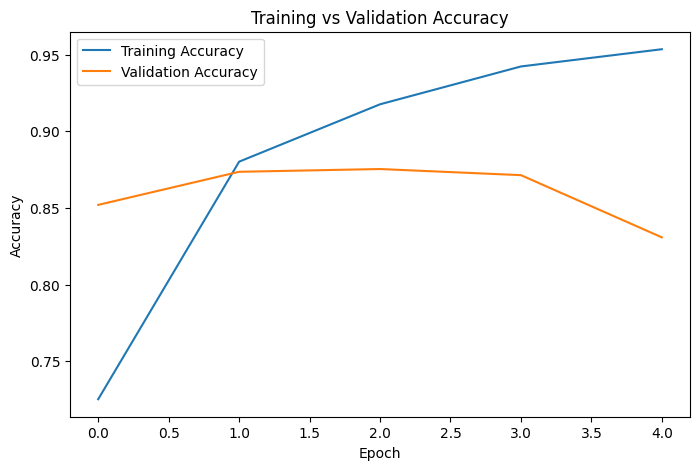

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [15]:
model.save("/content/imdb_sentiment_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [16]:
print("===== TASK 5 FINAL CHECK =====")
print("Training samples:", len(x_train))
print("Validation samples:", len(x_val))
print("Test samples:", len(x_test))
print("Vocabulary size:", len(vectorizer.get_vocabulary()))
print("Test accuracy:", test_accuracy)
print("Model saved:", os.path.exists("/content/imdb_sentiment_model.keras"))
print("================================")

===== TASK 5 FINAL CHECK =====
Training samples: 20000
Validation samples: 5000
Test samples: 25000
Vocabulary size: 20000
Test accuracy: 0.793720006942749
Model saved: True
